In [2]:
import pandas as pd
import os
import plotly.express as px

In [3]:
pcc = pd.read_csv('https://raw.githubusercontent.com/carleen/PCCAnalysis/main/pcc_new.csv')
grade_conversion = pd.read_csv('https://raw.githubusercontent.com/carleen/PCCAnalysis/main/grade_conv.csv')

'''
Change boulder grades to numbers
'''
'''
max_boulder_grades_num= {'<V3':3,
                        'I have not pursued bouldering goals outside in the past year': 1,
                        '? V3': 2}
for val in range(4,16):
    max_boulder_grades_num[f'V{val}'] = val
pcc=pcc.replace({'max_boulder':max_boulder_grades_num})
'''
pcc['max_boulder']=pcc['max_boulder'].map(grade_conversion.set_index('Vermin')['Gradeless'])    
pcc['max_boulder'] = pcc['max_boulder'].fillna(0)

'''
Clean up sex column
'''
sex_categories = {'Female': 'Female',
                 'Male': 'Male',
                 'Other/Prefer to Not Answer': 'Other',
                 'Other': 'Other'}
pcc = pcc.replace({'sex': sex_categories})
pcc['sex']=pcc['sex'].fillna('Other')

'''Clean up experience column'''
exp_cat = {'>10 years': 10,
          '7-8 years':7,
          '9-10 years':9,
          '5-6 years':5,
          '1-2 years':1,
          '3-4 years': 3,
          '<1 year': 0,
          '> 10 years': 10,
          '< 1 year': 1}
pcc = pcc.replace({'exp':exp_cat})
pcc['exp']=pcc['exp'].fillna(0)
pcc.exp.unique()

'''Replace sport grades with gradeless'''
pcc['max_sport']=pcc['max_sport'].map(grade_conversion.set_index('YDS')['Gradeless'])
pcc['max_sport']=pcc['max_sport'].fillna(0)

'''Replace rock type nan'''
pcc['rock']=pcc['rock'].fillna('Gym Only')

'''Replace maxhang nan'''
pcc['maxhang']=pcc['maxhang'].fillna(0)

'''Replace hang_score nan'''
pcc['hang_score']=pcc['hang_score'].fillna(0)

'''Replace pushup_score nan'''
pcc['pushup_score']=pcc['pushup_score'].fillna(0)

'''Replace pullup_score nan'''
pcc['pullup_score']=pcc['pullup_score'].fillna(0)

'''Create average score of max boulder/ max sport for each entry'''
pcc['max_climb_avg'] = pcc[['max_boulder', 'max_sport']].mean(axis=1)

In [4]:
pcc_male = pcc[pcc.sex=='Male']
pcc_female = pcc[pcc.sex=='Female']
pcc_male.columns
pcc_nozeros = pcc[pcc.maxhang>0]
pcc_nozeros = pcc_nozeros[pcc_nozeros.hang_score>0]
pcc_nozeros=pcc_nozeros[pcc_nozeros.max_sport>0]

pcc_ge_3 = pcc_nozeros[pcc_nozeros.max_boulder>2]

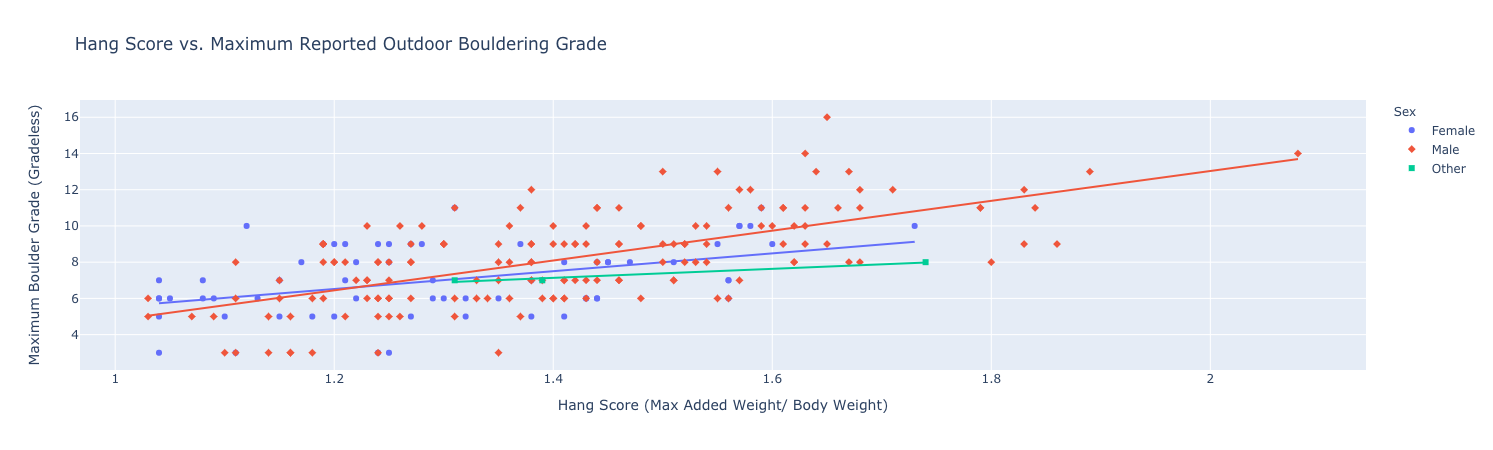

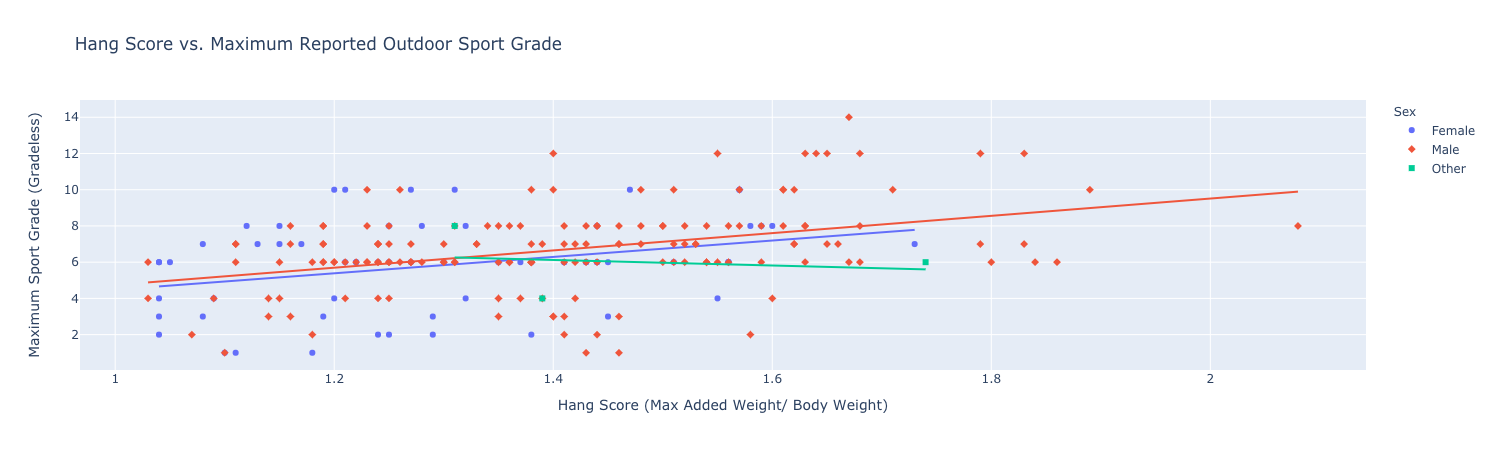

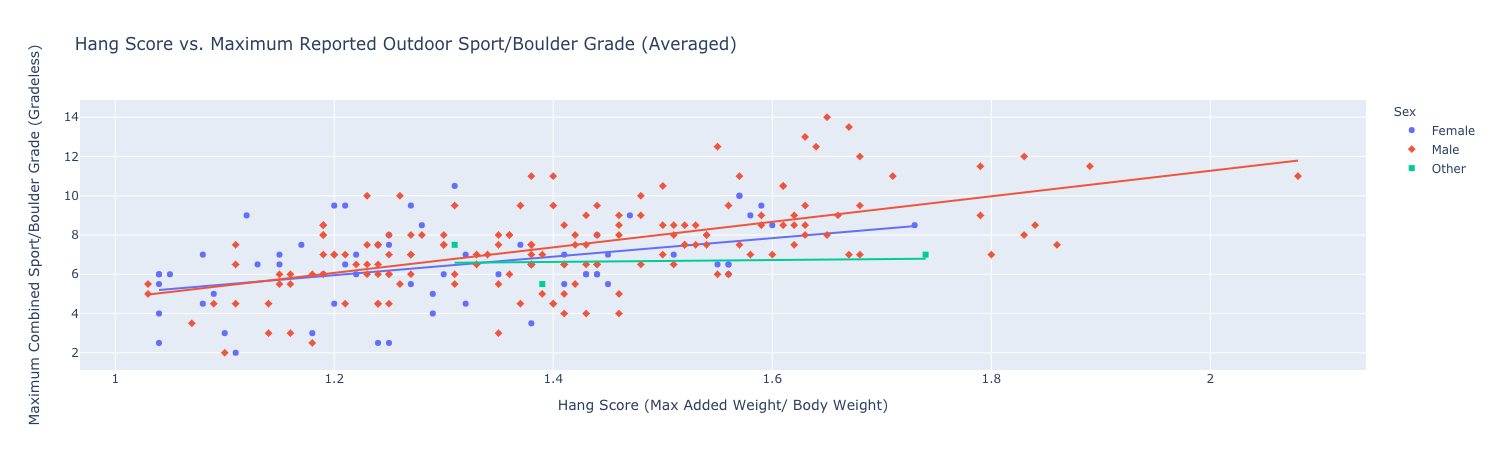

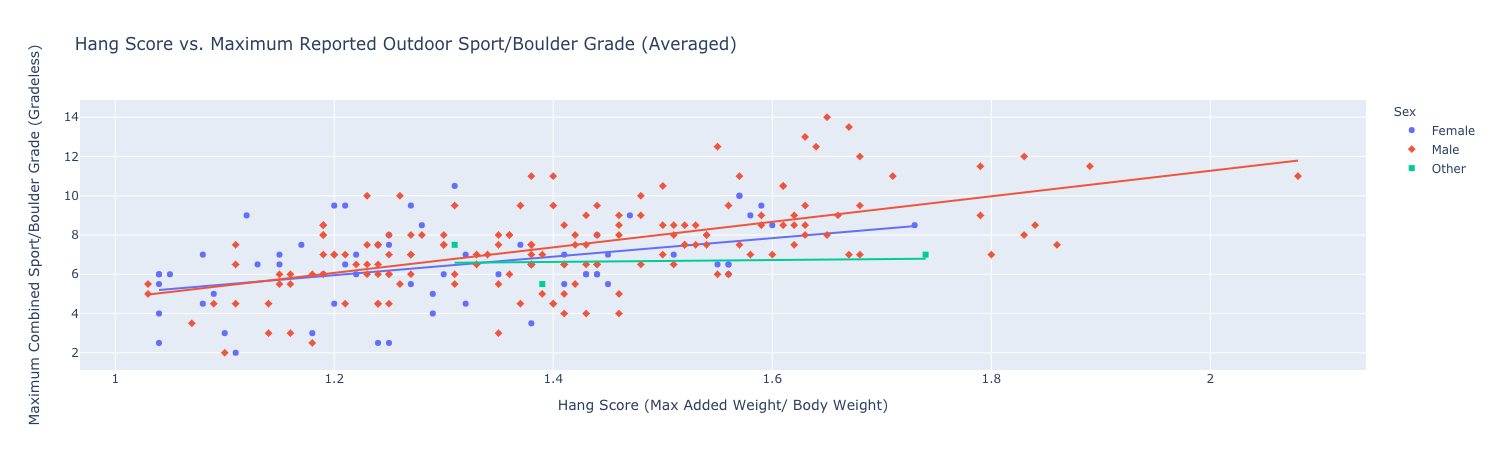

In [7]:
boulder_fig = px.scatter(pcc_ge_3,
          x='hang_score',
          y='max_boulder',
          color='sex',
          symbol='sex',
          trendline='ols',
          title='Hang Score vs. Maximum Reported Outdoor Bouldering Grade',
          labels = {'hang_score': 'Hang Score (Max Added Weight/ Body Weight)',
                   'max_boulder': 'Maximum Boulder Grade (Gradeless)',
                    'max_sport': 'Maximum Sport Grade (Gradeless)',
                   'sex': 'Sex'})
boulder_fig.show()

boulder_fig = px.scatter(pcc_ge_3,
          x='hang_score',
          y='max_sport',
          color='sex',
          symbol='sex',
          trendline='ols',
          title='Hang Score vs. Maximum Reported Outdoor Sport Grade',
          labels = {'hang_score': 'Hang Score (Max Added Weight/ Body Weight)',
                   'max_boulder': 'Maximum Boulder Grade (Gradeless)',
                    'max_sport': 'Maximum Sport Grade (Gradeless)',
                   'sex': 'Sex'})
boulder_fig.show()

average_fig = px.scatter(pcc_ge_3,
          x='hang_score',
          y='max_climb_avg',
          color='sex',
          symbol='sex',
          trendline='ols',
          title='Hang Score vs. Maximum Reported Outdoor Sport/Boulder Grade (Averaged)',
          labels = {'hang_score': 'Hang Score (Max Added Weight/ Body Weight)',
                   'max_boulder': 'Maximum Boulder Grade (Gradeless)',
                    'max_sport': 'Maximum Sport Grade (Gradeless)',
                    'max_climb_avg': 'Maximum Combined Sport/Boulder Grade (Gradeless)',
                   'sex': 'Sex'})
average_fig.show()

boulder_vs_sport = px.scatter(pcc_ge_3,
          x='max_boulder',
          y='max_sport',
          color='sex',
          symbol='sex',
          trendline='ols',
          title='Max Boulder Grade vs. Max Sport Grade',
          labels = {'hang_score': 'Hang Score (Max Added Weight/ Body Weight)',
                   'max_boulder': 'Maximum Boulder Grade (Gradeless)',
                    'max_sport': 'Maximum Sport Grade (Gradeless)',
                    'max_climb_avg': 'Maximum Combined Sport/Boulder Grade (Gradeless)',
                   'sex': 'Sex'})
average_fig.show()